# 머신러닝 분류

![image.png](attachment:image.png)

## k-NearestNeighbor(k-최근접이웃) 알고리즘

 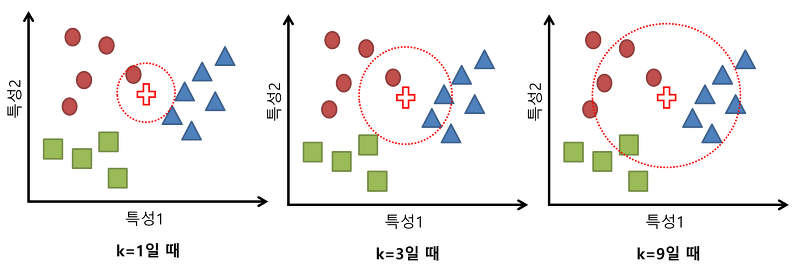

#붓꽃데이터 분류
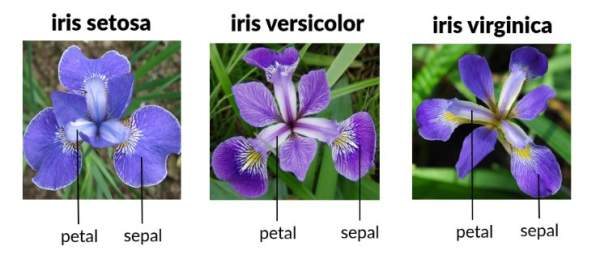

# 데이터 준비

In [1]:
import pandas as pd
import numpy as np

In [2]:
iris = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/iris.csv')

In [3]:
iris.head(5)

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [4]:
iris.head(10)

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


In [5]:
iris.tail()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
145,146,6.7,3.0,5.2,2.3,virginica
146,147,6.3,2.5,5.0,1.9,virginica
147,148,6.5,3.0,5.2,2.0,virginica
148,149,6.2,3.4,5.4,2.3,virginica
149,150,5.9,3.0,5.1,1.8,virginica


In [7]:
iris.describe()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.057333,3.758000,1.199333
std,43.445368,0.828066,0.435866,1.765298,0.762238
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   caseno       150 non-null    int64  
 1   SepalLength  150 non-null    float64
 2   SepalWidth   150 non-null    float64
 3   PetalLength  150 non-null    float64
 4   PetalWidth   150 non-null    float64
 5   Species      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
iris['Species']

,Species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [11]:
iris[['PetalLength','PetalWidth']]

,PetalLength,PetalWidth
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [12]:
np.unique(iris['Species'], return_counts=True)

(array(['setosa', 'versicolor', 'virginica'], dtype=object),
 array([50, 50, 50]))

In [14]:
iris.columns

Index(['caseno', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth',
       'Species'],
      dtype='object')

In [15]:
iris.values

array([[1, 5.1, 3.5, 1.4, 0.2, 'setosa'],
       [2, 4.9, 3.0, 1.4, 0.2, 'setosa'],
       [3, 4.7, 3.2, 1.3, 0.2, 'setosa'],
       [4, 4.6, 3.1, 1.5, 0.2, 'setosa'],
       [5, 5.0, 3.6, 1.4, 0.2, 'setosa'],
       [6, 5.4, 3.9, 1.7, 0.4, 'setosa'],
       [7, 4.6, 3.4, 1.4, 0.3, 'setosa'],
       [8, 5.0, 3.4, 1.5, 0.2, 'setosa'],
       [9, 4.4, 2.9, 1.4, 0.2, 'setosa'],
       [10, 4.9, 3.1, 1.5, 0.1, 'setosa'],
       [11, 5.4, 3.7, 1.5, 0.2, 'setosa'],
       [12, 4.8, 3.4, 1.6, 0.2, 'setosa'],
       [13, 4.8, 3.0, 1.4, 0.1, 'setosa'],
       [14, 4.3, 3.0, 1.1, 0.1, 'setosa'],
       [15, 5.8, 4.0, 1.2, 0.2, 'setosa'],
       [16, 5.7, 4.4, 1.5, 0.4, 'setosa'],
       [17, 5.4, 3.9, 1.3, 0.4, 'setosa'],
       [18, 5.1, 3.5, 1.4, 0.3, 'setosa'],
       [19, 5.7, 3.8, 1.7, 0.3, 'setosa'],
       [20, 5.1, 3.8, 1.5, 0.3, 'setosa'],
       [21, 5.4, 3.4, 1.7, 0.2, 'setosa'],
       [22, 5.1, 3.7, 1.5, 0.4, 'setosa'],
       [23, 4.6, 3.6, 1.0, 0.2, 'setosa'],
       [24, 5.1, 3.3

In [16]:
iris = iris[['PetalLength', 'PetalWidth', 'Species']]

In [17]:
iris.head()

,PetalLength,PetalWidth,Species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


In [ ]:
type(iris.values)

In [ ]:
iris.head()

In [18]:
setosa = iris[iris.Species=='setosa']
virginica = iris[iris.Species == 'virginica']
versicolor = iris[iris.Species == 'versicolor']

In [22]:
import matplotlib.pyplot as plt

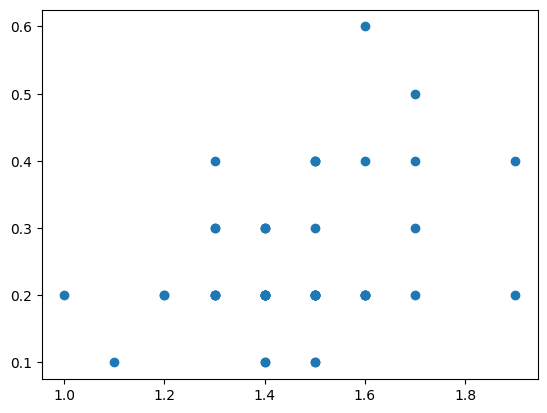

In [23]:
plt.scatter(setosa['PetalLength'], setosa['PetalWidth'])

In [26]:
setosa = setosa.to_numpy()
virginica = virginica.to_numpy()
versicolor = versicolor.to_numpy()

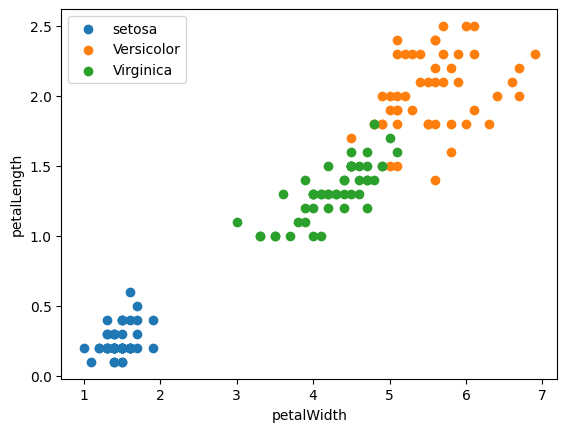

In [27]:
plt.scatter(setosa[:, 0], setosa[:,1])
plt.scatter(virginica[:, 0], virginica[:,1])
plt.scatter(versicolor[:, 0], versicolor[:,1])
plt.xlabel('petalWidth')
plt.ylabel('petalLength')
plt.legend(['setosa', 'Versicolor', 'Virginica'])
plt.show()

## Data와 Target분리

In [33]:
iris_input = iris[['PetalLength','PetalWidth']]
iris_target = iris['Species']

In [34]:
print(iris_input.shape)
print(iris_target.shape)

(150, 2)
(150,)


## Dataframe을 Numpy ndarray로 변환

In [35]:
iris.input = iris_input.to_numpy()
iris.target = iris_target.to_numpy()
print(iris_input)
print(iris_target)

     PetalLength  PetalWidth
0            1.4         0.2
1            1.4         0.2
2            1.3         0.2
3            1.5         0.2
4            1.4         0.2
..           ...         ...
145          5.2         2.3
146          5.0         1.9
147          5.2         2.0
148          5.4         2.3
149          5.1         1.8

[150 rows x 2 columns]
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: object


/tmp/ipykernel_379/3097675476.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  iris.input = iris_input.to_numpy()
/tmp/ipykernel_379/3097675476.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  iris.target = iris_target.to_numpy()


In [36]:
iris_input.shape

(150, 2)

In [ ]:
import matplotlib.pyplot as plt

## Train, Test용 데이터분리

In [47]:
from sklearn.model_selection import train_test_split

In [49]:
train_input, test_input, train_target, test_target \
= train_test_split(iris_input, iris_target, test_size=0.2, random_state=42)

In [51]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(120, 2) (120,)
(30, 2) (30,)


In [50]:
train_input

,PetalLength,PetalWidth
22,1.0,0.2
15,1.5,0.4
65,4.4,1.4
11,1.6,0.2
42,1.3,0.2
...,...,...
71,4.0,1.3
106,4.5,1.7
14,1.2,0.2
92,4.0,1.2


## 표준화

In [46]:
from sklearn.preprocessing import StandardScaler

In [52]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [53]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(120, 2) (120,)
(30, 2) (30,)


In [54]:
train_scaled

array([[-1.56253475, -1.31260282],
       [-1.27600637, -1.04563275],
       [ 0.38585821,  0.28921757],
       [-1.2187007 , -1.31260282],
       [-1.39061772, -1.31260282],
       [ 0.72969227,  0.95664273],
       [ 0.44316389,  0.4227026 ],
       [-1.27600637, -1.31260282],
       [-1.33331205, -1.31260282],
       [-1.27600637, -1.44608785],
       [ 0.78699794,  0.95664273],
       [ 0.44316389,  0.55618763],
       [ 0.55777524,  0.4227026 ],
       [-1.39061772, -1.04563275],
       [-1.27600637, -1.31260282],
       [-0.01528151, -0.24472256],
       [ 0.78699794,  0.4227026 ],
       [ 1.01622064,  0.8231577 ],
       [ 0.38585821,  0.28921757],
       [ 1.3600547 ,  1.75755292],
       [ 0.27124686,  0.15573254],
       [ 1.64658307,  1.22361279],
       [ 0.44316389,  0.4227026 ],
       [-1.33331205, -1.31260282],
       [ 1.70388875,  1.09012776],
       [ 0.21394119, -0.24472256],
       [-1.33331205, -1.31260282],
       [-1.39061772, -1.17911778],
       [-1.04678367,

# k-최근접 이웃 다중분류

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
kn = KNeighborsClassifier()
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [57]:
kn.score(test_scaled, test_target)

1.0

In [58]:
kn = KNeighborsClassifier(3)
kn.fit(train_scaled, train_target)

KNeighborsClassifier(n_neighbors=3)

In [69]:
kn.score(test_scaled, test_target)

1.0

In [70]:
#K 값을 바꿔가면서 함
k_nums = [1,3,5,7,9]
for k in k_nums:
  kn = KNeighborsClassifier(k)
  kn.fit(train_scaled, train_target)
  print('k={} : {}'.format(k, kn.score(test_scaled, test_target)))

k=1 : 1.0
k=3 : 1.0
k=5 : 1.0
k=7 : 1.0
k=9 : 1.0


In [66]:
kn.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [75]:
print(test_target[20:30]) #[0:10])

29        setosa
127    virginica
26        setosa
128    virginica
131    virginica
145    virginica
108    virginica
143    virginica
45        setosa
30        setosa
Name: Species, dtype: object


In [76]:
kn.predict(test_scaled[20:30])

array(['setosa', 'virginica', 'setosa', 'virginica', 'virginica',
       'virginica', 'virginica', 'virginica', 'setosa', 'setosa'],
      dtype=object)

In [77]:
kn.predict_proba(test_scaled[20:30])

array([[1.        , 0.        , 0.        ],
       [0.        , 0.22222222, 0.77777778],
       [1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ]])

In [ ]:
[5.7, 2.3]